In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

CSV_PATH = "results_stage150.csv"
CONFIDENCE_LEVEL = 0.95

In [27]:
df_raw = pd.read_csv(CSV_PATH)

if df_raw['cpu_pct'].dtype == object:
    df_raw['cpu_pct'] = df_raw['cpu_pct'].astype(str).str.rstrip('%').astype(float)

print(f"Всего строк загружено: {len(df_raw)}")
print(f"Распределение по типам запусков:\n{df_raw['run_type'].value_counts()}\n")

df_warmup = df_raw[df_raw['run_type'] == 'warmup'].copy()
df = df_raw[df_raw['run_type'] == 'test'].copy()

print(f"Зачётных измерений для анализа: {len(df)} (по {len(df)//2} на каждый режим)")
df.head()

Всего строк загружено: 302
Распределение по типам запусков:
run_type
test      300
warmup      2
Name: count, dtype: int64

Зачётных измерений для анализа: 300 (по 150 на каждый режим)


,timestamp,run_type,run_id,mode,wall_s,user_s,sys_s,cpu_pct,vol_ctx,invol_ctx,maj_flt,min_flt,max_rss_kb
2,1790531603,test,1,cache,0.16,0.04,0.12,98%,1,1,0,229,2240
3,1790531603,test,1,nocache,28.31,0.24,1.62,6%,307029,10,0,232,2176
4,1790531631,test,2,cache,0.16,0.02,0.13,98%,1,1,0,227,2240
5,1790531632,test,2,nocache,28.26,0.22,1.63,6%,307029,6,0,230,2236
6,1790531660,test,3,cache,0.16,0.04,0.11,99%,1,1,0,229,2240


In [28]:
def compute_statistics(group, target_col='wall_s', conf=CONFIDENCE_LEVEL):
    data = group[target_col].to_numpy()
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)  # Несмещённое стандартное отклонение (s)
    sem = std / np.sqrt(n)       # Стандартная ошибка среднего (SEM)
    
    # Квантиль распределения Стьюдента t_(1-a/2, n-1)
    t_crit = stats.t.ppf((1 + conf) / 2.0, df=n - 1)
    margin_of_error = t_crit * sem
    
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error
    rel_error = (margin_of_error / mean) * 100  # Относительная погрешность ДИ в %

    return pd.Series({
        'N': int(n),
        'Mean [s]': mean,
        'Std [s]': std,
        'SEM [s]': sem,
        't_crit': t_crit,
        'CI_Margin [s]': margin_of_error,
        'CI_Lower [s]': ci_lower,
        'CI_Upper [s]': ci_upper,
        'Rel_Error [%]': rel_error,
        'Min [s]': np.min(data),
        'Max [s]': np.max(data)
    })

# Агрегация по режимам
stats_summary = df.groupby('mode').apply(compute_statistics, include_groups=False)
display(stats_summary.style.format({
    'Mean [s]': '{:.5f}',
    'Std [s]': '{:.5f}',
    'SEM [s]': '{:.5f}',
    'CI_Margin [s]': '{:.5f}',
    'CI_Lower [s]': '{:.5f}',
    'CI_Upper [s]': '{:.5f}',
    'Rel_Error [%]': '{:.2f}%',
    'Min [s]': '{:.5f}',
    'Max [s]': '{:.5f}'
}))

,N,Mean [s],Std [s],SEM [s],t_crit,CI_Margin [s],CI_Lower [s],CI_Upper [s],Rel_Error [%],Min [s],Max [s]
mode,,,,,,,,,,,
cache,150.000000,0.15967,0.00316,0.00026,1.976013,0.00051,0.15916,0.16018,0.32%,0.15000,0.17000
nocache,150.000000,28.24400,0.34560,0.02822,1.976013,0.05576,28.18824,28.29976,0.20%,27.53000,30.24000


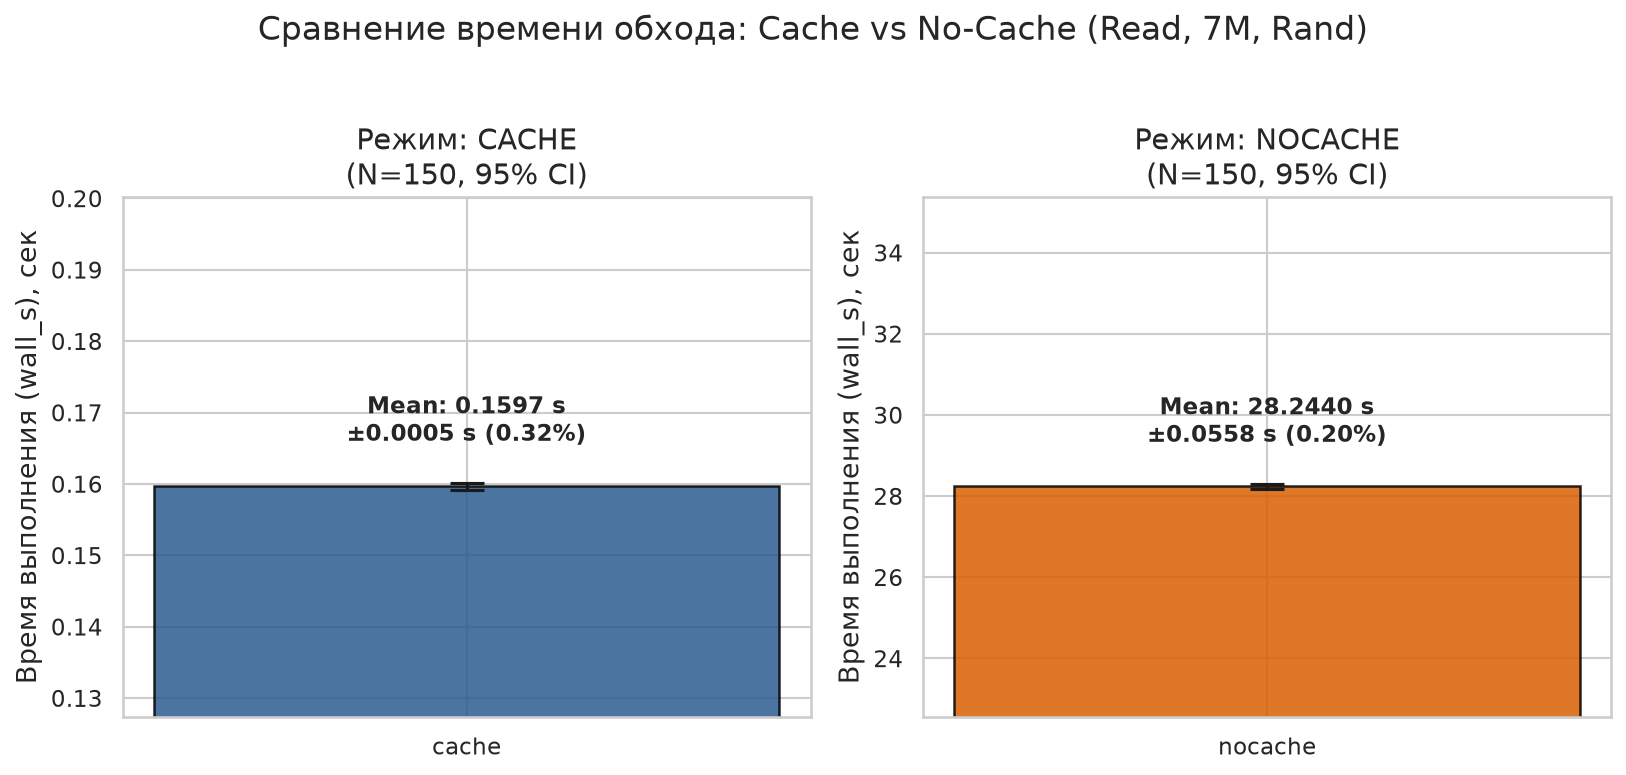

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

modes = ['cache', 'nocache']
colors = ['#2b5c8f', '#d95f02']

for ax, mode, color in zip(axes, modes, colors):
    row = stats_summary.loc[mode]
    mean = row['Mean [s]']
    margin = row['CI_Margin [s]']
    
    # Столбец среднего
    bar = ax.bar(mode, mean, yerr=margin, capsize=8, color=color, alpha=0.85, 
                 edgecolor='black', linewidth=1.2, error_kw=dict(lw=1.5, capthick=1.5))
    
    # Подписи значений над баром
    ax.text(0, mean + margin + (mean * 0.03), 
            f"Mean: {mean:.4f} s\n±{margin:.4f} s ({row['Rel_Error [%]']:.2f}%)", 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel("Время выполнения (wall_s), сек")
    ax.set_title(f"Режим: {mode.upper()}\n(N={int(row['N'])}, 95% CI)")
    
    # Добавляем запас по Y для читаемости погрешностей
    y_max = (mean + margin) * 1.25
    y_min = max(0, (mean - margin) * 0.8)
    ax.set_ylim(y_min, y_max)

plt.suptitle("Сравнение времени обхода: Cache vs No-Cache (Read, 7M, Rand)", y=1.03)
plt.tight_layout()
plt.savefig("stage1_barplot_ci.png", bbox_inches='tight')
plt.show()

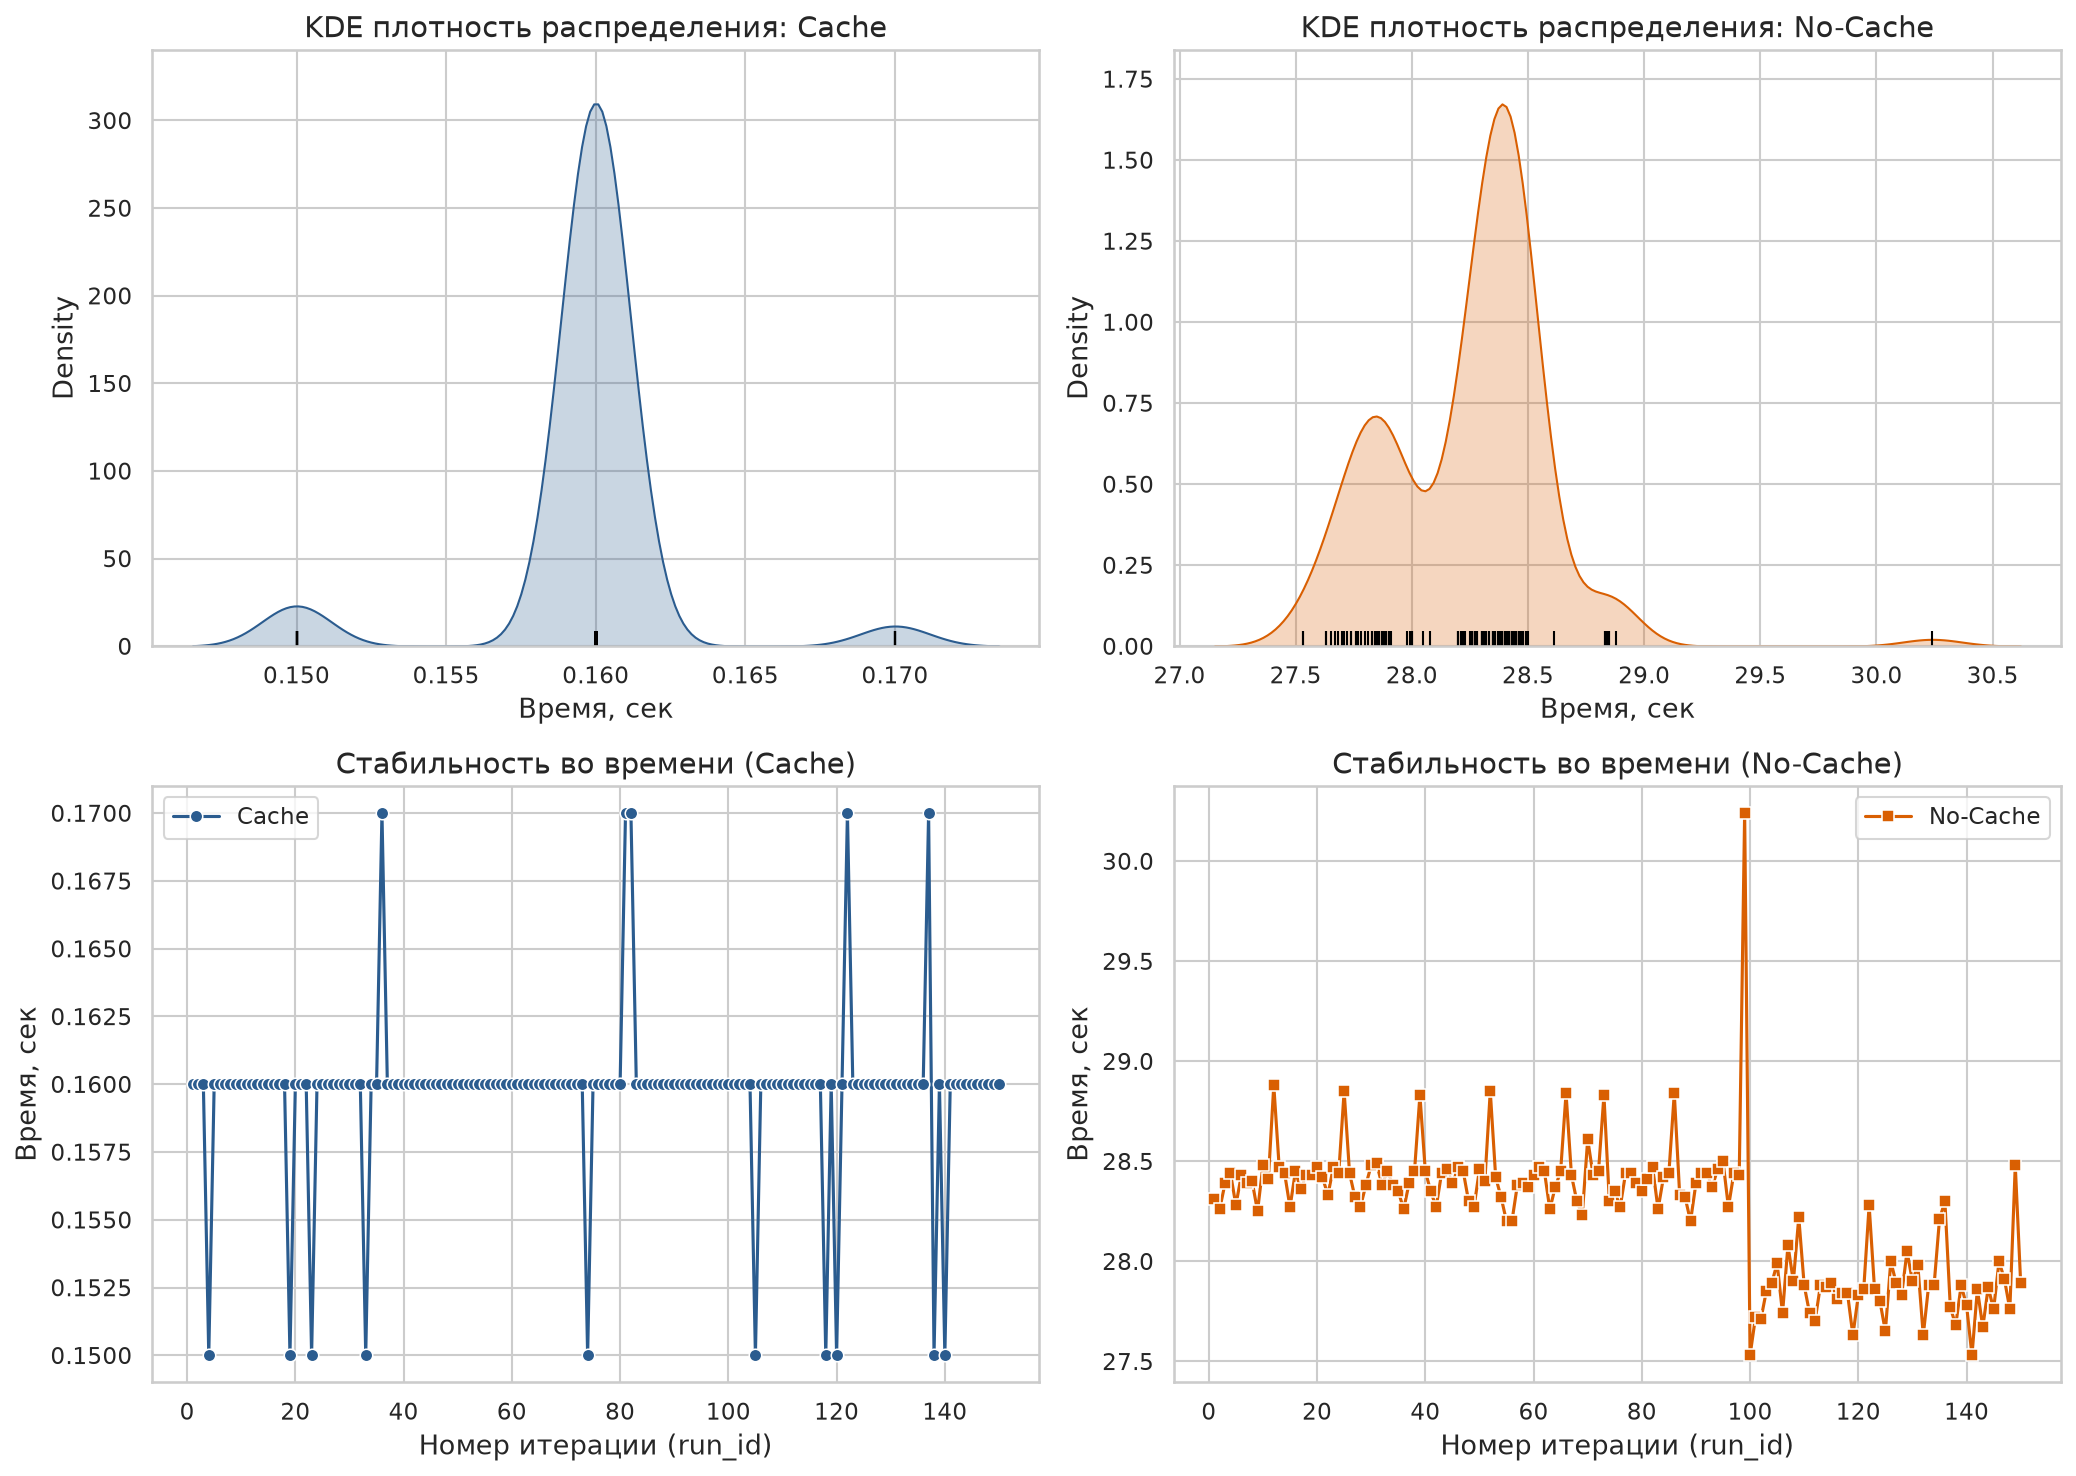

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. KDE распределения для Cache
sns.kdeplot(data=df[df['mode'] == 'cache'], x='wall_s', ax=axes[0, 0], fill=True, color=colors[0])
sns.rugplot(data=df[df['mode'] == 'cache'], x='wall_s', ax=axes[0, 0], color='black')
axes[0, 0].set_title("KDE плотность распределения: Cache")
axes[0, 0].set_xlabel("Время, сек")

# 2. KDE распределения для No-Cache
sns.kdeplot(data=df[df['mode'] == 'nocache'], x='wall_s', ax=axes[0, 1], fill=True, color=colors[1])
sns.rugplot(data=df[df['mode'] == 'nocache'], x='wall_s', ax=axes[0, 1], color='black')
axes[0, 1].set_title("KDE плотность распределения: No-Cache")
axes[0, 1].set_xlabel("Время, сек")

# 3. Проверка временного дрейфа (Interleaving stability)
sns.lineplot(data=df[df['mode'] == 'cache'], x='run_id', y='wall_s', ax=axes[1, 0], 
             marker='o', color=colors[0], label='Cache')
axes[1, 0].set_title("Стабильность во времени (Cache)")
axes[1, 0].set_xlabel("Номер итерации (run_id)")
axes[1, 0].set_ylabel("Время, сек")

sns.lineplot(data=df[df['mode'] == 'nocache'], x='run_id', y='wall_s', ax=axes[1, 1], 
             marker='s', color=colors[1], label='No-Cache')
axes[1, 1].set_title("Стабильность во времени (No-Cache)")
axes[1, 1].set_xlabel("Номер итерации (run_id)")
axes[1, 1].set_ylabel("Время, сек")

plt.tight_layout()
plt.savefig("stage1_distributions.png", bbox_inches='tight')
plt.show()


=== СРЕДНИЕ СИСТЕМНЫЕ МЕТРИКИ ПО РЕЖИМАМ ===


,user_s,sys_s,vol_ctx,invol_ctx,maj_flt,cpu_pct
mode,,,,,,
cache,0.0314 s,0.1218 s,1,1.2,0.0,98.5%
nocache,0.2202 s,1.6213 s,"307,030",10.5,0.0,6.0%


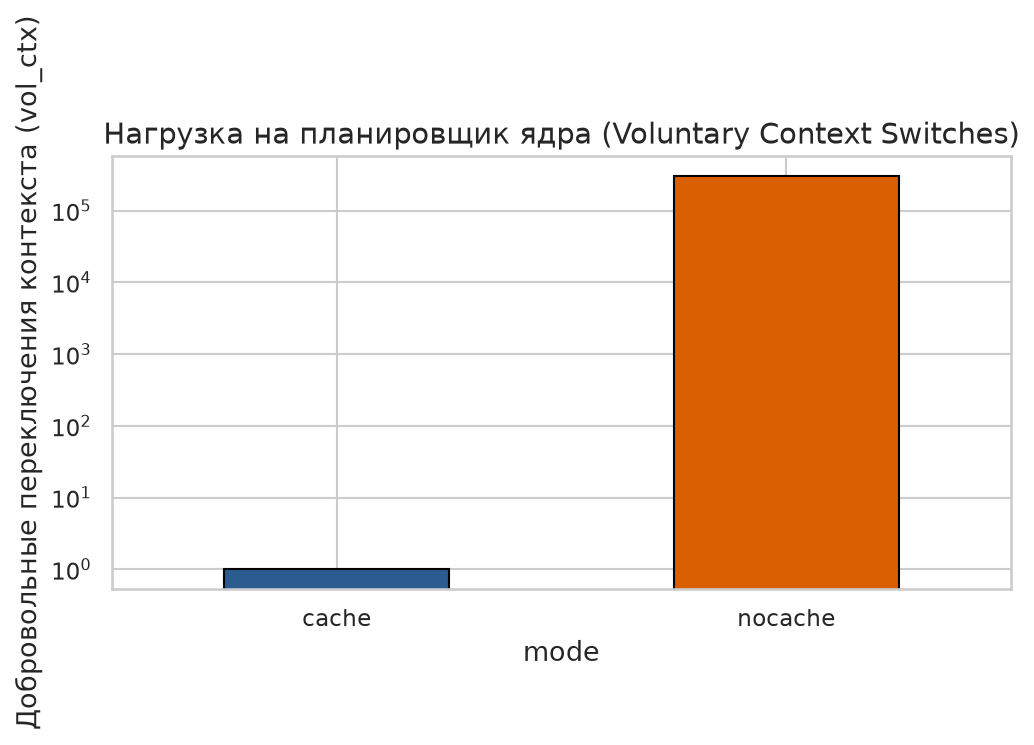

In [31]:
# Список целевых колонок
target_cols = ['user_s', 'sys_s', 'vol_ctx', 'invol_ctx', 'maj_flt', 'cpu_pct']

# Гарантированно очищаем и приводим все колонки к числовому типу (float)
for col in target_cols:
    if col in df.columns:
        if col == 'cpu_pct':
            df[col] = df[col].astype(str).str.replace('%', '', regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Считаем среднее с явным указанием numeric_only=True
os_metrics = df.groupby('mode')[target_cols].mean(numeric_only=True)

print("=== СРЕДНИЕ СИСТЕМНЫЕ МЕТРИКИ ПО РЕЖИМАМ ===")
display(os_metrics.style.format({
    'user_s': '{:.4f} s',
    'sys_s': '{:.4f} s',
    'vol_ctx': '{:,.0f}',
    'invol_ctx': '{:.1f}',
    'maj_flt': '{:.1f}',
    'cpu_pct': '{:.1f}%'
}))

# График соотношения добровольных переключений контекста
fig, ax = plt.subplots(figsize=(7, 4))
os_metrics['vol_ctx'].plot(kind='bar', ax=ax, color=['#2b5c8f', '#d95f02'], edgecolor='black')
ax.set_ylabel("Добровольные переключения контекста (vol_ctx)")
ax.set_title("Нагрузка на планировщик ядра (Voluntary Context Switches)")
ax.set_yscale('log')  # Логарифмическая шкала, так как разница колоссальная
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("stage1_context_switches.png", bbox_inches='tight')
plt.show()

In [32]:
print("=" * 70)
print(" ВЫЧИСЛЕНИЕ ДОСТАТОЧНОСТИ ВЫБОРКИ (ОТВЕТЫ НА ШАГ 4.9)")
print("=" * 70)

DESIRED_PRECISION_PCT = 3.0  # Желаемая погрешность: 3% от среднего

for mode in ['cache', 'nocache']:
    row = stats_summary.loc[mode]
    mean = row['Mean [s]']
    std = row['Std [s]']
    t_val = row['t_crit']
    cur_n = int(row['N'])
    cur_rel_err = row['Rel_Error [%]']
    
    # Допустимая погрешность Delta в секундах
    delta = (DESIRED_PRECISION_PCT / 100.0) * mean
    
    # Расчёт требуемого N
    n_required = int(np.ceil((t_val * std / delta) ** 2))
    
    print(f"\nРежим: [{mode.upper()}]")
    print(f"  - Текущий размер выборки N: {cur_n}")
    print(f"  - Текущая относительная ширина ДИ: ±{cur_rel_err:.2f}%")
    print(f"  - Требуемый N для достижения точности ±{DESIRED_PRECISION_PCT}%: {n_required}")
    
    if cur_n >= n_required:
        print(f"  -> ВЫВОД: Выборка N={cur_n} ДОСТАТОЧНА (погрешность {cur_rel_err:.2f}% < {DESIRED_PRECISION_PCT}%).")
    else:
        print(f"  -> ВЫВОД: Требуется увеличить выборку до N={n_required}.")

# Проверка пересечения ДИ
cache_upper = stats_summary.loc['cache', 'CI_Upper [s]']
nocache_lower = stats_summary.loc['nocache', 'CI_Lower [s]']
print("\n" + "-" * 70)
print("ПРОВЕРКА ПЕРЕСЕЧЕНИЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ:")
print(f"Cache 95% CI Upper:   {cache_upper:.5f} s")
print(f"No-Cache 95% CI Lower: {nocache_lower:.5f} s")
if cache_upper < nocache_lower:
    diff_factor = stats_summary.loc['nocache', 'Mean [s]'] / stats_summary.loc['cache', 'Mean [s]']
    print(f"-> Доверительные интервалы НЕ пересекаются.")
    print(f"-> Различие статистически достоверно: No-Cache медленнее в {diff_factor:.1f} раз.")
else:
    print("-> Доверительные интервалы пересекаются (различие статистически незначимо).")
print("=" * 70)

 ВЫЧИСЛЕНИЕ ДОСТАТОЧНОСТИ ВЫБОРКИ (ОТВЕТЫ НА ШАГ 4.9)

Режим: [CACHE]
  - Текущий размер выборки N: 150
  - Текущая относительная ширина ДИ: ±0.32%
  - Требуемый N для достижения точности ±3.0%: 2
  -> ВЫВОД: Выборка N=150 ДОСТАТОЧНА (погрешность 0.32% < 3.0%).

Режим: [NOCACHE]
  - Текущий размер выборки N: 150
  - Текущая относительная ширина ДИ: ±0.20%
  - Требуемый N для достижения точности ±3.0%: 1
  -> ВЫВОД: Выборка N=150 ДОСТАТОЧНА (погрешность 0.20% < 3.0%).

----------------------------------------------------------------------
ПРОВЕРКА ПЕРЕСЕЧЕНИЯ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ:
Cache 95% CI Upper:   0.16018 s
No-Cache 95% CI Lower: 28.18824 s
-> Доверительные интервалы НЕ пересекаются.
-> Различие статистически достоверно: No-Cache медленнее в 176.9 раз.
